In [ ]:
import hashlib
import json
import math
import os
import struct
import uuid
from dataclasses import dataclass, field

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import least_squares

OUT_DIR = "/content" if os.path.isdir("/content") else os.getcwd()
IN_COLAB = os.path.isdir("/content")


def banner(text):
    print("\n" + "=" * 78)
    print(text)
    print("=" * 78)


@dataclass
class Entity:
    kind: str
    uuid: str

    points: dict = field(default_factory=dict)
    extra: dict = field(default_factory=dict)


class Sketch:
    """A parameter block + entity table + constraint list, i.e. a Dune 3D sketch group."""

    def __init__(self):
        self.x0 = []
        self.entities = {}
        self.constraints = []
        self.order = []


    def _param(self, value):
        self.x0.append(float(value))
        return len(self.x0) - 1

    def _pt(self, xy):
        return ("var", self._param(xy[0]), self._param(xy[1]))

    def _register(self, ent):
        self.entities[ent.uuid] = ent
        self.order.append(ent.uuid)
        return ent.uuid


    def line(self, p1, p2):
        e = Entity("line_2d", str(uuid.uuid4()))
        e.points = {1: self._pt(p1), 2: self._pt(p2)}
        return self._register(e)

    def circle(self, center, radius):
        e = Entity("circle_2d", str(uuid.uuid4()))
        e.points = {1: self._pt(center)}
        e.extra["radius_param"] = self._param(radius)
        return self._register(e)

    def arc(self, frm, to, center):
        """CCW from -> to, matching Dune 3D / SolveSpace arc orientation."""
        e = Entity("arc_2d", str(uuid.uuid4()))
        e.points = {1: self._pt(frm), 2: self._pt(to), 3: self._pt(center)}
        return self._register(e)

    def origin(self):
        """The reference workplane's origin: a point that is NOT a free parameter.

        In Dune 3D this is the XY workplane entity generated by the reference group;
        sketches anchor themselves to it. Here it is simply a fixed (0, 0)."""
        e = Entity("workplane_origin", str(uuid.uuid4()))
        e.points = {1: ("fixed", 0.0, 0.0)}
        return self._register(e)


    def xy(self, x, ep):
        """ep = (entity_uuid, point_index) -> np.array([px, py])"""
        ent_uu, idx = ep
        p = self.entities[ent_uu].points[idx]
        if p[0] == "var":
            return np.array([x[p[1]], x[p[2]]])
        return np.array([p[1], p[2]])

    def radius(self, x, ent_uu):
        e = self.entities[ent_uu]
        if e.kind == "circle_2d":
            return x[e.extra["radius_param"]]
        if e.kind == "arc_2d":
            return np.linalg.norm(self.xy(x, (ent_uu, 1)) - self.xy(x, (ent_uu, 3)))
        raise TypeError(e.kind)


    def c(self, ctype, **kw):
        kw["type"] = ctype
        self.constraints.append(kw)
        return kw

    def coincident(self, ep1, ep2):
        return self.c("points_coincident", entity1=ep1, entity2=ep2)

    def horizontal(self, ep1, ep2):
        return self.c("horizontal", entity1=ep1, entity2=ep2)

    def vertical(self, ep1, ep2):
        return self.c("vertical", entity1=ep1, entity2=ep2)

    def dist_h(self, ep1, ep2, distance):
        """Signed: Dune 3D measures (p2 - p1).x  (see ConstraintPointDistanceBase)."""
        return self.c("point_distance_horizontal", entity1=ep1, entity2=ep2, distance=distance)

    def dist_v(self, ep1, ep2, distance):
        return self.c("point_distance_vertical", entity1=ep1, entity2=ep2, distance=distance)

    def radius_c(self, ent, distance):
        return self.c("radius", entity=ent, distance=distance)

    def diameter(self, ent, distance):
        return self.c("diameter", entity=ent, distance=distance)

    def equal_radius(self, e1, e2):
        return self.c("equal_radius", entity1=e1, entity2=e2)

    def tangent(self, arc, arc_point, line):
        return self.c("arc_line_tangent", arc=(arc, arc_point), line=line)


    def residuals(self, x):
        r = []
        for con in self.constraints:
            t = con["type"]

            if t == "points_coincident":
                d = self.xy(x, con["entity1"]) - self.xy(x, con["entity2"])
                r.extend([d[0], d[1]])

            elif t == "horizontal":
                r.append(self.xy(x, con["entity1"])[1] - self.xy(x, con["entity2"])[1])

            elif t == "vertical":
                r.append(self.xy(x, con["entity1"])[0] - self.xy(x, con["entity2"])[0])

            elif t == "point_distance_horizontal":
                d = self.xy(x, con["entity2"])[0] - self.xy(x, con["entity1"])[0]
                r.append(d - con["distance"])

            elif t == "point_distance_vertical":
                d = self.xy(x, con["entity2"])[1] - self.xy(x, con["entity1"])[1]
                r.append(d - con["distance"])

            elif t == "point_distance":
                d = np.linalg.norm(self.xy(x, con["entity2"]) - self.xy(x, con["entity1"]))
                r.append(d - con["distance"])

            elif t == "radius":
                r.append(self.radius(x, con["entity"]) - con["distance"])

            elif t == "diameter":
                r.append(2.0 * self.radius(x, con["entity"]) - con["distance"])

            elif t == "equal_radius":
                r.append(self.radius(x, con["entity1"]) - self.radius(x, con["entity2"]))

            elif t == "equal_length":
                a = self.xy(x, (con["entity1"], 2)) - self.xy(x, (con["entity1"], 1))
                b = self.xy(x, (con["entity2"], 2)) - self.xy(x, (con["entity2"], 1))
                r.append(np.linalg.norm(a) - np.linalg.norm(b))

            elif t == "point_on_line":
                a = self.xy(x, (con["line"], 1))
                b = self.xy(x, (con["line"], 2))
                p = self.xy(x, con["point"])
                r.append(np.cross(b - a, p - a) / max(np.linalg.norm(b - a), 1e-9))

            elif t == "midpoint":
                a = self.xy(x, (con["line"], 1))
                b = self.xy(x, (con["line"], 2))
                d = self.xy(x, con["point"]) - 0.5 * (a + b)
                r.extend([d[0], d[1]])

            elif t == "arc_line_tangent":
                arc_uu, ap = con["arc"]
                p = self.xy(x, (arc_uu, ap))
                c = self.xy(x, (arc_uu, 3))
                a = self.xy(x, (con["line"], 1))
                b = self.xy(x, (con["line"], 2))
                ldir = b - a
                n = max(np.linalg.norm(ldir), 1e-9)
                r.append(np.dot(p - c, ldir) / n)

            else:
                raise NotImplementedError(t)


        for uu in self.order:
            e = self.entities[uu]
            if e.kind == "arc_2d":
                c = self.xy(x, (uu, 3))
                r.append(np.linalg.norm(self.xy(x, (uu, 1)) - c)
                         - np.linalg.norm(self.xy(x, (uu, 2)) - c))
        return np.array(r)


    def solve(self, x_start=None, verbose=True):
        x0 = np.array(self.x0 if x_start is None else x_start, dtype=float)
        sol = least_squares(self.residuals, x0, method="lm", xtol=1e-14, ftol=1e-14, max_nfev=20000)
        if verbose:
            print(f"  parameters      : {len(x0)}")
            print(f"  equations       : {len(sol.fun)}")
            print(f"  residual |r|    : {np.linalg.norm(sol.fun):.3e}  "
                  f"({'CONVERGED' if np.linalg.norm(sol.fun) < 1e-8 else 'NOT CONVERGED'})")
            print(f"  function evals  : {sol.nfev}")
        return sol.x

In [ ]:
def jacobian(sk, x, eps=1e-7):
    r0 = sk.residuals(x)
    J = np.zeros((len(r0), len(x)))
    for k in range(len(x)):
        xp = x.copy()
        h = eps * max(1.0, abs(x[k]))
        xp[k] += h
        J[:, k] = (sk.residuals(xp) - r0) / h
    return J


def analyse(sk, x):
    J = jacobian(sk, x)
    rank = np.linalg.matrix_rank(J, tol=1e-6)
    dof = J.shape[1] - rank
    redundant = J.shape[0] - rank
    print(f"  Jacobian        : {J.shape[0]} x {J.shape[1]}   rank = {rank}")
    print(f"  degrees of free.: {dof}   -> {'fully constrained' if dof == 0 else 'UNDER-CONSTRAINED'}")
    print(f"  redundant eqs.  : {redundant}   -> {'none' if redundant == 0 else 'REDUNDANT/CONFLICTING'}")
    return dof, redundant


def build_plate(W=90.0, H=60.0, R=12.0, D=6.5, noise=3.0, seed=7):
    """Return (sketch, tags). Geometry starts deliberately WRONG; the solver fixes it."""
    rng = np.random.default_rng(seed)
    sk = Sketch()

    def n(p):
        return (p[0] + rng.normal(0, noise), p[1] + rng.normal(0, noise))

    hw, hh = W / 2.0, H / 2.0

    cbl, cbr = (-hw + R, -hh + R), (hw - R, -hh + R)
    ctr, ctl = (hw - R, hh - R), (-hw + R, hh - R)

    org = sk.origin()


    bottom = sk.line(n((cbl[0], -hh)), n((cbr[0], -hh)))
    right = sk.line(n((hw, cbr[1])), n((hw, ctr[1])))
    top = sk.line(n((ctr[0], hh)), n((ctl[0], hh)))
    left = sk.line(n((-hw, ctl[1])), n((-hw, cbl[1])))


    a_bl = sk.arc(n((-hw, cbl[1])), n((cbl[0], -hh)), n(cbl))
    a_br = sk.arc(n((cbr[0], -hh)), n((hw, cbr[1])), n(cbr))
    a_tr = sk.arc(n((hw, ctr[1])), n((ctr[0], hh)), n(ctr))
    a_tl = sk.arc(n((ctl[0], hh)), n((-hw, ctl[1])), n(ctl))


    h_bl = sk.circle(n(cbl), D / 2 + rng.normal(0, 0.4))
    h_br = sk.circle(n(cbr), D / 2 + rng.normal(0, 0.4))
    h_tr = sk.circle(n(ctr), D / 2 + rng.normal(0, 0.4))
    h_tl = sk.circle(n(ctl), D / 2 + rng.normal(0, 0.4))


    sk.coincident((a_bl, 2), (bottom, 1))
    sk.coincident((bottom, 2), (a_br, 1))
    sk.coincident((a_br, 2), (right, 1))
    sk.coincident((right, 2), (a_tr, 1))
    sk.coincident((a_tr, 2), (top, 1))
    sk.coincident((top, 2), (a_tl, 1))
    sk.coincident((a_tl, 2), (left, 1))
    sk.coincident((left, 2), (a_bl, 1))


    sk.horizontal((bottom, 1), (bottom, 2))
    sk.horizontal((top, 1), (top, 2))
    sk.vertical((right, 1), (right, 2))
    sk.vertical((left, 1), (left, 2))


    sk.tangent(a_bl, 1, left);  sk.tangent(a_bl, 2, bottom)
    sk.tangent(a_br, 1, bottom); sk.tangent(a_br, 2, right)
    sk.tangent(a_tr, 1, right); sk.tangent(a_tr, 2, top)
    sk.tangent(a_tl, 1, top);   sk.tangent(a_tl, 2, left)


    sk.equal_radius(a_bl, a_br); sk.equal_radius(a_br, a_tr); sk.equal_radius(a_tr, a_tl)
    sk.equal_radius(h_bl, h_br); sk.equal_radius(h_br, h_tr); sk.equal_radius(h_tr, h_tl)


    sk.coincident((h_bl, 1), (a_bl, 3))
    sk.coincident((h_br, 1), (a_br, 3))
    sk.coincident((h_tr, 1), (a_tr, 3))
    sk.coincident((h_tl, 1), (a_tl, 3))


    sk.dist_h((a_bl, 3), (a_br, 3), W - 2 * R)
    sk.dist_v((a_bl, 3), (a_tl, 3), H - 2 * R)
    sk.radius_c(a_bl, R)
    sk.diameter(h_bl, D)


    sk.dist_h((org, 1), (a_bl, 3), -(W / 2 - R))
    sk.dist_v((org, 1), (a_bl, 3), -(H / 2 - R))

    tags = dict(origin=org, bottom=bottom, right=right, top=top, left=left,
                a_bl=a_bl, a_br=a_br, a_tr=a_tr, a_tl=a_tl,
                h_bl=h_bl, h_br=h_br, h_tr=h_tr, h_tl=h_tl,
                params=dict(W=W, H=H, R=R, D=D))
    return sk, tags

In [ ]:
def arc_points(frm, to, center, seg_len=0.6):
    """Tessellate a CCW arc from 'frm' to 'to' about 'center' (endpoints excluded at 'to')."""
    r = np.linalg.norm(frm - center)
    a0 = math.atan2(frm[1] - center[1], frm[0] - center[0])
    a1 = math.atan2(to[1] - center[1], to[0] - center[0])
    sweep = (a1 - a0) % (2 * math.pi)
    if sweep < 1e-12:
        sweep = 2 * math.pi
    n = max(2, int(math.ceil(r * sweep / seg_len)))
    return [center + r * np.array([math.cos(a0 + sweep * i / n), math.sin(a0 + sweep * i / n)])
            for i in range(n)]


def circle_points(center, r, seg_len=0.6):
    n = max(12, int(math.ceil(2 * math.pi * r / seg_len)))
    return [center + r * np.array([math.cos(2 * math.pi * i / n), math.sin(2 * math.pi * i / n)])
            for i in range(n)]


def signed_area(poly):
    p = np.asarray(poly)
    q = np.roll(p, -1, axis=0)
    return 0.5 * np.sum(p[:, 0] * q[:, 1] - q[:, 0] * p[:, 1])


def extract_loops(sk, x, tags, seg_len=0.6):
    """Return (outer CCW loop, [hole loops CW]) as lists of 2D points."""
    t = tags
    outer = []
    seq = [("arc", t["a_bl"]), ("line", t["bottom"]), ("arc", t["a_br"]), ("line", t["right"]),
           ("arc", t["a_tr"]), ("line", t["top"]), ("arc", t["a_tl"]), ("line", t["left"])]
    for kind, uu in seq:
        if kind == "line":
            outer.append(sk.xy(x, (uu, 1)))
        else:
            outer.extend(arc_points(sk.xy(x, (uu, 1)), sk.xy(x, (uu, 2)),
                                    sk.xy(x, (uu, 3)), seg_len))
    if signed_area(outer) < 0:
        outer = outer[::-1]

    holes = []
    for key in ("h_bl", "h_br", "h_tr", "h_tl"):
        uu = t[key]
        loop = circle_points(sk.xy(x, (uu, 1)), sk.radius(x, uu), seg_len)
        if signed_area(loop) > 0:
            loop = loop[::-1]
        holes.append(loop)
    return outer, holes


def _cross2(o, a, b):
    return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])


def _in_triangle(p, a, b, c, eps=1e-12):
    d1, d2, d3 = _cross2(a, b, p), _cross2(b, c, p), _cross2(c, a, p)
    return (d1 > eps and d2 > eps and d3 > eps) or (d1 < -eps and d2 < -eps and d3 < -eps)


def bridge_holes(outer, holes):
    """Eberly's algorithm: cut each hole into the outer loop, making one simple polygon."""
    poly = [np.asarray(p, float) for p in outer]
    for hole in sorted(holes, key=lambda h: -max(p[0] for p in h)):
        hole = [np.asarray(p, float) for p in hole]
        m = int(np.argmax([p[0] for p in hole]))
        M = hole[m]


        best_x, best_edge = np.inf, None
        for i in range(len(poly)):
            a, b = poly[i], poly[(i + 1) % len(poly)]
            if (a[1] > M[1]) == (b[1] > M[1]):
                continue
            tpar = (M[1] - a[1]) / (b[1] - a[1])
            xi = a[0] + tpar * (b[0] - a[0])
            if xi > M[0] - 1e-12 and xi < best_x:
                best_x, best_edge = xi, i
        if best_edge is None:
            raise RuntimeError("hole outside outer loop")

        i0, i1 = best_edge, (best_edge + 1) % len(poly)

        cand = [i0, i1]
        cand.sort(key=lambda i: (-poly[i][0], abs(poly[i][1] - M[1])))
        p_idx = cand[0]
        I = np.array([best_x, M[1]])
        P = poly[p_idx]


        best_cos, chosen = -np.inf, p_idx
        for j in range(len(poly)):
            if j == p_idx:
                continue
            v = poly[j]
            if not _in_triangle(v, M, I, P):
                continue
            prv, nxt = poly[(j - 1) % len(poly)], poly[(j + 1) % len(poly)]
            if _cross2(prv, v, nxt) > 0:
                continue
            d = v - M
            nrm = np.linalg.norm(d)
            if nrm < 1e-12:
                continue
            cos = d[0] / nrm
            if cos > best_cos:
                best_cos, chosen = cos, j

        merged = hole[m:] + hole[:m] + [hole[m]]
        poly = poly[:chosen + 1] + merged + poly[chosen:]
    return poly


def earclip(poly):
    """O(n^2) ear clipping of a simple CCW polygon (duplicated bridge vertices allowed)."""
    idx = list(range(len(poly)))
    tris, guard = [], 0
    while len(idx) > 3 and guard < 100000:
        guard += 1
        clipped = False
        for i in range(len(idx)):
            ia, ib, ic = idx[i - 1], idx[i], idx[(i + 1) % len(idx)]
            a, b, c = poly[ia], poly[ib], poly[ic]
            if _cross2(a, b, c) <= 1e-12:
                continue
            ok = True
            for j in idx:
                if j in (ia, ib, ic):
                    continue
                p = poly[j]
                if (np.allclose(p, a) or np.allclose(p, b) or np.allclose(p, c)):
                    continue
                if _in_triangle(p, a, b, c):
                    ok = False
                    break
            if ok:
                tris.append((ia, ib, ic))
                idx.pop(i)
                clipped = True
                break
        if not clipped:
            break
    if len(idx) == 3:
        tris.append(tuple(idx))
    return tris


def extrude(outer, holes, height):
    """Build a watertight triangle mesh: bottom cap + top cap + side walls."""
    poly = bridge_holes(outer, holes)
    tris = earclip(poly)
    P = np.asarray(poly)

    verts, faces = [], []

    def add(p, z):
        verts.append((p[0], p[1], z))
        return len(verts) - 1

    bot = [add(p, 0.0) for p in P]
    top = [add(p, height) for p in P]
    for (a, b, c) in tris:
        faces.append((bot[a], bot[c], bot[b]))
        faces.append((top[a], top[b], top[c]))

    for loop in [outer] + holes:
        L = [np.asarray(p, float) for p in loop]
        base = len(verts)
        for p in L:
            add(p, 0.0)
        for p in L:
            add(p, height)
        n = len(L)
        for i in range(n):
            j = (i + 1) % n
            b0, b1 = base + i, base + j
            t0, t1 = base + n + i, base + n + j
            faces.append((b0, b1, t1))
            faces.append((b0, t1, t0))
    return np.asarray(verts, float), np.asarray(faces, int), tris, P


def mesh_volume(V, F):
    a, b, c = V[F[:, 0]], V[F[:, 1]], V[F[:, 2]]
    return float(np.sum(np.einsum("ij,ij->i", a, np.cross(b, c))) / 6.0)


def write_binary_stl(path, V, F, name="dune3d_plate"):
    with open(path, "wb") as f:
        f.write(name.encode("ascii", "replace").ljust(80, b"\0")[:80])
        f.write(struct.pack("<I", len(F)))
        for tri in F:
            a, b, c = V[tri[0]], V[tri[1]], V[tri[2]]
            nrm = np.cross(b - a, c - a)
            ln = np.linalg.norm(nrm)
            nrm = nrm / ln if ln > 1e-15 else np.zeros(3)
            f.write(struct.pack("<12fH", *nrm, *a, *b, *c, 0))
    return path

In [ ]:
NS_XY = "7f7519bb-0bff-4240-a188-d8d235e7cd68"
NS_YZ = "5411b06d-e1f8-49b5-a134-332026e96533"
NS_ZX = "8fdb3da1-0536-4338-8a07-aa1f697ccc65"
NIL = "00000000-0000-0000-0000-000000000000"
FILE_VERSION = 27


def hash_uuids(ns, uuids):
    """Reimplementation of dune3d::hash_uuids() -> RFC 4122 v5 over raw UUID bytes."""
    data = b"".join(uuid.UUID(u).bytes for u in uuids)
    h = bytearray(hashlib.sha1(uuid.UUID(ns).bytes + data).digest()[:16])
    h[6] = (h[6] & 0x0F) | 0x50
    h[8] = (h[8] & 0x3F) | 0x80
    return str(uuid.UUID(bytes=bytes(h)))


def ep(entity, point):
    return {"entity": entity, "point": point}


def write_d3ddoc(path, sk, x, tags, thickness, sketch_name="Plate outline"):
    ref_g = str(uuid.uuid4())
    sketch_g = str(uuid.uuid4())
    extrude_g = str(uuid.uuid4())
    wp_xy = hash_uuids(NS_XY, [ref_g])

    P = tags["params"]
    groups = {
        ref_g: {
            "type": "reference", "index": 0, "name": "References",
            "body": {"name": "Plate"}, "active_wrkpl": NIL,
            "show_xy": True, "show_yz": False, "show_zx": False,
            "xy_size": [P["W"] * 1.3, P["H"] * 1.3],
            "yz_size": [10.0, 10.0], "zx_size": [10.0, 10.0],
        },
        sketch_g: {
            "type": "sketch", "index": 1, "name": sketch_name,
            "body": None, "active_wrkpl": wp_xy, "operation": "union",
        },
        extrude_g: {
            "type": "extrude", "index": 2, "name": f"Extrude {thickness} mm",
            "body": None, "active_wrkpl": NIL,
            "wrkpl": wp_xy, "source_group": sketch_g, "operation": "union",
            "direction": "normal", "mode": "single",
            "dvec": [0.0, 0.0, float(thickness)],
        },
    }


    entities = {}
    for uu in sk.order:
        e = sk.entities[uu]
        if e.kind == "workplane_origin":
            continue
        base = {"type": e.kind, "group": sketch_g, "name": "", "construction": False,
                "wrkpl": wp_xy}
        if e.kind == "line_2d":
            base["p1"] = list(map(float, sk.xy(x, (uu, 1))))
            base["p2"] = list(map(float, sk.xy(x, (uu, 2))))
        elif e.kind == "circle_2d":
            base["center"] = list(map(float, sk.xy(x, (uu, 1))))
            base["radius"] = float(sk.radius(x, uu))
        elif e.kind == "arc_2d":
            base["from"] = list(map(float, sk.xy(x, (uu, 1))))
            base["to"] = list(map(float, sk.xy(x, (uu, 2))))
            base["center"] = list(map(float, sk.xy(x, (uu, 3))))
        else:
            raise TypeError(e.kind)
        entities[uu] = base


    origin_uu = tags["origin"]

    def to_ep(pair):
        """Map our (entity, point) onto Dune 3D's; the fixed origin becomes (XY plane, 1)."""
        e, i = pair
        return ep(wp_xy, 1) if e == origin_uu else ep(e, i)

    constraints = {}
    for con in sk.constraints:
        t = con["type"]
        j = {"type": t, "group": sketch_g}
        if t == "points_coincident":
            j.update(entity1=to_ep(con["entity1"]), entity2=to_ep(con["entity2"]), wrkpl=wp_xy)
        elif t in ("horizontal", "vertical"):
            j.update(entity1=to_ep(con["entity1"]), entity2=to_ep(con["entity2"]), wrkpl=wp_xy)
        elif t in ("point_distance_horizontal", "point_distance_vertical"):
            j.update(entity1=to_ep(con["entity1"]), entity2=to_ep(con["entity2"]),
                     distance=float(con["distance"]), wrkpl=wp_xy, offset=[0.0, 0.0, 4.0])
        elif t in ("radius", "diameter"):
            j.update(entity=con["entity"], distance=float(con["distance"]), offset=[6.0, 6.0])
        elif t == "equal_radius":
            j.update(entity1=con["entity1"], entity2=con["entity2"])
        elif t == "arc_line_tangent":
            arc_uu, ap = con["arc"]
            j.update(arc=ep(arc_uu, ap), line=con["line"])
        else:
            raise NotImplementedError(t)
        constraints[str(uuid.uuid4())] = j

    doc = {"type": "document", "version": FILE_VERSION,
           "groups": groups, "entities": entities, "constraints": constraints}
    with open(path, "w") as f:
        json.dump(doc, f, indent=4, sort_keys=True)
    return path, wp_xy

In [ ]:
def plot_sketch(ax, sk, x, tags, title, color):
    for uu in sk.order:
        e = sk.entities[uu]
        if e.kind == "line_2d":
            a, b = sk.xy(x, (uu, 1)), sk.xy(x, (uu, 2))
            ax.plot([a[0], b[0]], [a[1], b[1]], "-", color=color, lw=1.8)
        elif e.kind == "arc_2d":
            pts = np.array(arc_points(sk.xy(x, (uu, 1)), sk.xy(x, (uu, 2)),
                                      sk.xy(x, (uu, 3)), 0.4) + [sk.xy(x, (uu, 2))])
            ax.plot(pts[:, 0], pts[:, 1], "-", color=color, lw=1.8)
        elif e.kind == "circle_2d":
            pts = np.array(circle_points(sk.xy(x, (uu, 1)), sk.radius(x, uu), 0.3))
            ax.plot(np.append(pts[:, 0], pts[0, 0]), np.append(pts[:, 1], pts[0, 1]),
                    "-", color=color, lw=1.4)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.axhline(0, color="0.7", lw=0.6)
    ax.axvline(0, color="0.7", lw=0.6)


def plot_solid(V, F, title):
    fig = plt.figure(figsize=(9, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.add_collection3d(Poly3DCollection(V[F], facecolor="#c8a678", edgecolor="#4a3b28",
                                         linewidths=0.15, alpha=1.0))
    lo, hi = V.min(axis=0), V.max(axis=0)
    ctr, span = (lo + hi) / 2, (hi - lo).max() / 2
    ax.set_xlim(ctr[0] - span, ctr[0] + span)
    ax.set_ylim(ctr[1] - span, ctr[1] + span)
    ax.set_zlim(ctr[2] - span, ctr[2] + span)
    ax.view_init(elev=32, azim=-52)
    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()


PART 1+3 — build the sketch and solve it
  entities        : 12   constraints: 36
  start residual  : 26.5145  (sloppy input)
  parameters      : 52
  equations       : 52
  residual |r|    : 0.000e+00  (CONVERGED)
  function evals  : 5

PART 2 — degrees of freedom / redundancy (Jacobian rank)
  Jacobian        : 52 x 52   rank = 52
  degrees of free.: 0   -> fully constrained
  redundant eqs.  : 0   -> none

Verification against the driving dimensions
  corner radius   : 12.000000   (asked 12.0)
  overall width   : 90.000000   (asked 90.0)
  overall height  : 60.000000   (asked 60.0)
  hole diameter   : 6.500000   (asked 6.5)
  plate centroid  : (+0.000000, +0.000000)


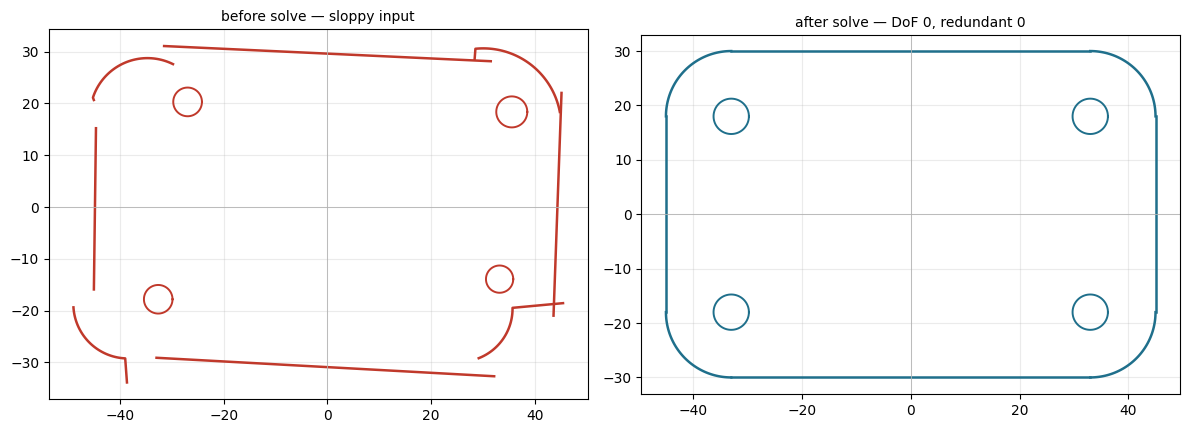


PART 4 — sketch -> solid -> STL
  loops           : 1 outer (132 pts) + 4 holes
  cap triangles   : 278   total mesh triangles: 1100
  face area check : triangulated 5144.1872 vs analytic 5144.1872 -> OK
  mesh volume     : 41153.4975 mm^3 vs area*t 41153.4975 -> watertight
  wrote           : /content/dune3d_plate.stl


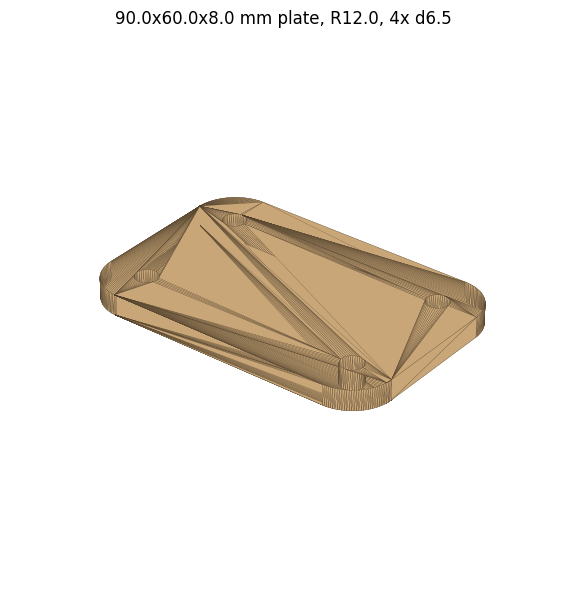


PART 5 — write a real .d3ddoc you can open in Dune 3D
  derived XY plane: 898ca260-962f-5850-9395-3981e576303d
  wrote           : /content/plate.d3ddoc  (21.8 kB)
  groups          : reference(0) -> sketch(1) -> extrude(2), body 'Plate'
  open it with    : dune3d plate.d3ddoc

PART 6 — parametric rebuild sweep
       W      H      R      D |       |r|  DoF   volume mm^3
      90     60     12    6.5 |  0.00e+00    0      41156.98   -> plate_90x60_r12_d6.5.stl
     120     60     20      8 |  0.00e+00    0      39939.25   -> plate_120x60_r20_d8.stl
      70     70     30      5 |  0.00e+00    0      40498.45   -> plate_70x70_r30_d5.stl
     140     45     10    4.2 |  0.00e+00    0      30798.36   -> plate_140x45_r10_d4.2.stl

DONE
Files written to: /content

Where to go next
  * Open plate.d3ddoc in Dune 3D, drag a corner: the solver keeps every constraint.
    Double-click a dimension to change W/H/R/D and watch the extrude regenerate.
  * Add a 'chamfer' or 'fillet' group in the ap

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
if __name__ == "__main__":

    W, H, R, D, THK = 90.0, 60.0, 12.0, 6.5, 8.0

    banner("PART 1+3 — build the sketch and solve it")
    sk, tags = build_plate(W, H, R, D, noise=3.0)
    x_start = np.array(sk.x0)
    print(f"  entities        : {len(sk.entities) - 1}   constraints: {len(sk.constraints)}")
    print(f"  start residual  : {np.linalg.norm(sk.residuals(x_start)):.4f}  (sloppy input)")
    x = sk.solve()

    banner("PART 2 — degrees of freedom / redundancy (Jacobian rank)")
    dof, redundant = analyse(sk, x)

    banner("Verification against the driving dimensions")
    c_bl = sk.xy(x, (tags["a_bl"], 3)); c_br = sk.xy(x, (tags["a_br"], 3))
    c_tl = sk.xy(x, (tags["a_tl"], 3))
    print(f"  corner radius   : {sk.radius(x, tags['a_bl']):.6f}   (asked {R})")
    print(f"  overall width   : {c_br[0] - c_bl[0] + 2 * R:.6f}   (asked {W})")
    print(f"  overall height  : {c_tl[1] - c_bl[1] + 2 * R:.6f}   (asked {H})")
    print(f"  hole diameter   : {2 * sk.radius(x, tags['h_tr']):.6f}   (asked {D})")
    print(f"  plate centroid  : ({(c_bl[0] + c_br[0]) / 2:+.6f}, {(c_bl[1] + c_tl[1]) / 2:+.6f})")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
    plot_sketch(axes[0], sk, x_start, tags, "before solve — sloppy input", "#c0392b")
    plot_sketch(axes[1], sk, x, tags, f"after solve — DoF {dof}, redundant {redundant}", "#1f6f8b")
    plt.tight_layout(); plt.show()

    banner("PART 4 — sketch -> solid -> STL")
    outer, holes = extract_loops(sk, x, tags, seg_len=0.6)
    V, F, tris, P = extrude(outer, holes, THK)
    area_expected = abs(signed_area(outer)) - sum(abs(signed_area(h)) for h in holes)
    area_tri = sum(abs(_cross2(P[a], P[b], P[c])) / 2 for a, b, c in tris)
    vol = mesh_volume(V, F)
    print(f"  loops           : 1 outer ({len(outer)} pts) + {len(holes)} holes")
    print(f"  cap triangles   : {len(tris)}   total mesh triangles: {len(F)}")
    print(f"  face area check : triangulated {area_tri:.4f} vs analytic {area_expected:.4f} "
          f"-> {'OK' if abs(area_tri - area_expected) < 1e-6 * max(1, area_expected) else 'MISMATCH'}")
    print(f"  mesh volume     : {vol:.4f} mm^3 vs area*t {area_expected * THK:.4f} "
          f"-> {'watertight' if abs(vol - area_expected * THK) < 1e-6 * abs(vol) else 'LEAKY'}")
    stl = write_binary_stl(os.path.join(OUT_DIR, "dune3d_plate.stl"), V, F)
    print(f"  wrote           : {stl}")
    plot_solid(V, F, f"{W}x{H}x{THK} mm plate, R{R}, 4x d{D}")

    banner("PART 5 — write a real .d3ddoc you can open in Dune 3D")
    d3d, wp_xy = write_d3ddoc(os.path.join(OUT_DIR, "plate.d3ddoc"), sk, x, tags, THK)
    print(f"  derived XY plane: {wp_xy}")
    print(f"  wrote           : {d3d}  ({os.path.getsize(d3d) / 1024:.1f} kB)")
    print("  groups          : reference(0) -> sketch(1) -> extrude(2), body 'Plate'")
    print("  open it with    : dune3d plate.d3ddoc")

    banner("PART 6 — parametric rebuild sweep")
    print(f"  {'W':>6} {'H':>6} {'R':>6} {'D':>6} | {'|r|':>9} {'DoF':>4} {'volume mm^3':>13}")
    for (w, h, r, d, t) in [(90, 60, 12, 6.5, 8), (120, 60, 20, 8.0, 6),
                            (70, 70, 30, 5.0, 10), (140, 45, 10, 4.2, 5)]:
        s2, t2 = build_plate(w, h, r, d, noise=2.0, seed=3)
        x2 = s2.solve(verbose=False)
        o2, hl2 = extract_loops(s2, x2, t2, seg_len=0.8)
        V2, F2, _, _ = extrude(o2, hl2, t)
        J = jacobian(s2, x2)
        dof2 = J.shape[1] - np.linalg.matrix_rank(J, tol=1e-6)
        name = f"plate_{w:g}x{h:g}_r{r:g}_d{d:g}.stl"
        write_binary_stl(os.path.join(OUT_DIR, name), V2, F2)
        write_d3ddoc(os.path.join(OUT_DIR, name.replace(".stl", ".d3ddoc")), s2, x2, t2, t)
        print(f"  {w:6g} {h:6g} {r:6g} {d:6g} | {np.linalg.norm(s2.residuals(x2)):9.2e} "
              f"{dof2:4d} {mesh_volume(V2, F2):13.2f}   -> {name}")

    banner("DONE")
    print("Files written to:", OUT_DIR)
    print("""
Where to go next
  * Open plate.d3ddoc in Dune 3D, drag a corner: the solver keeps every constraint.
    Double-click a dimension to change W/H/R/D and watch the extrude regenerate.
  * Add a 'chamfer' or 'fillet' group in the app - those reference OpenCASCADE *edge
    indices*, which only exist after the kernel builds the solid, so they cannot
    sensibly be authored offline the way the sketch can.
  * Extend the solver: 'point_on_line', 'midpoint', 'equal_length' and 'point_distance'
    are already implemented above; 'arc_arc_tangent' and 'symmetric' are good exercises.
  * Constraints not yet in residuals() will raise NotImplementedError - by design, so
    the exporter never emits something the solver has not validated.
""")
    if IN_COLAB:
        try:
            from google.colab import files
            for f in ("plate.d3ddoc", "dune3d_plate.stl"):
                files.download(os.path.join(OUT_DIR, f))
        except Exception as exc:
            print("(download skipped:", exc, ")")